# Hybrid CNN + MLP classifier

Two branches. The CNN reads the hit-level dE/dx sequence; the MLP reads
track-level summary statistics. Their outputs are concatenated and classified
end to end.

Set `TARGET` to `"pion"` or `"photon"` — everything else follows.

**Feature ablation.** The summary branch now carries provenance variables
(`b`, `d`, `beam_angle`) alongside the original four. Photon purity is limited
by `γ:other` — real photons not from the beam π⁰ — which is indistinguishable
from signal in every variable the classifier previously saw. These new ones
encode *where the shower came from*, which is the only remaining handle.

Five configurations are trained with identical initialisation, so the only
difference between them is the input. `base4` is the control and should
reproduce the previous result.

## setup

In [4]:
import json
import pickle
import time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_curve, auc as sk_auc

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS, SPECIES_ALL,
                                 species_label, target_config,
                                 purity, efficiency, create_confusion_matrix)
from utils.evaluation_utils import (plot_training_curves, optimise_threshold,
                                    plot_roc_and_purity_efficiency,
                                    save_results, combine_pdfs)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

TARGET = "photon"          # "pion" | "photon"
cfg    = target_config(TARGET)
BASE   = "hybrid_cnn_mlp"

# Which configuration becomes "the" hybrid downstream. Cell 11 copies its
# predictions to the unsuffixed filename that model-comparison,
# topology-selection and the analysis notebooks already read.
HEADLINE = "all8"

# Evaluating the training set every epoch roughly doubles the time per epoch,
# since it is ~5x the size of the test set. Set to 5 to do it every 5th epoch.
TRAIN_EVAL_EVERY = 1

# Which configurations to train this run. Set to None for all five.
RUN_ONLY = ['base4', 'all8']
TRAIN_EVAL_EVERY = 1

PREPARED_DIR      = PROJECT_ROOT / "prepared" / "prepared-mc"
PREPARED_DATA_DIR = PROJECT_ROOT / "prepared" / "prepared-data"
PRED_MC_DIR       = PROJECT_ROOT / "predictions" / "predictions-mc"
PRED_DATA_DIR     = PROJECT_ROOT / "predictions" / "predictions-data"
MODELS_DIR        = PROJECT_ROOT / "models"
PLOTS_DIR         = PROJECT_ROOT / "plots" / "hybrid-classifier" / TARGET
for d in (PRED_MC_DIR, PRED_DATA_DIR, MODELS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

DATA_PRED_PATH = PRED_DATA_DIR / f"hybrid_data_predictions{cfg['suffix']}.pkl"

print(f"target: {TARGET} ({cfg['signal_name']})   headline: {HEADLINE}")

Using device: cpu
target: photon ($\gamma$ (beam $\pi^0$))   headline: all8


## data and feature sets

In [5]:
data_size = "all"

with open(PREPARED_DIR / f"train_{data_size}.pkl", "rb") as f:
    train = pickle.load(f)
with open(PREPARED_DIR / "test.pkl", "rb") as f:
    test = pickle.load(f)

seq_train,  seq_test  = train["sequences"][:, :, 0:1], test["sequences"][:, :, 0:1]
mask_train, mask_test = train["masks"],  test["masks"]
y_train,    y_test    = train[cfg['label_key']], test[cfg['label_key']]

# Column order comes from data-preparation via norm_stats, never hardcoded
# here, so the notebook cannot drift from what was actually prepared.
with open(PREPARED_DIR / "norm_stats.pkl", "rb") as f:
    ALL_FEATURES = pickle.load(f)["summary_features"]
COL = {k: i for i, k in enumerate(ALL_FEATURES)}
print(f"prepared summary ({len(ALL_FEATURES)}): {ALL_FEATURES}")

BASE4 = ['track_chi2/ndof_proton', 'track_length', 'track_score', 'dEdX_median']

FEATURE_SETS = {
    'base4':      BASE4,
    'plus_bd':    BASE4 + ['b', 'd'],
    'plus_E':     BASE4 + ['shower_energy'],
    'plus_angle': BASE4 + ['beam_angle'],
    'all8':       BASE4 + ['b', 'd', 'shower_energy', 'beam_angle'],
}

COLOURS = {'base4': 'grey', 'plus_bd': 'steelblue', 'plus_E': 'darkorange',
           'plus_angle': 'mediumseagreen', 'all8': 'crimson'}

for name, feats in FEATURE_SETS.items():
    missing = [f for f in feats if f not in COL]
    assert not missing, f"{name}: {missing} not present in the prepared summary"
assert HEADLINE in FEATURE_SETS, f"HEADLINE={HEADLINE} is not a configuration"

if RUN_ONLY:
    FEATURE_SETS = {k: v for k, v in FEATURE_SETS.items() if k in RUN_ONLY}
    print(f"running only: {list(FEATURE_SETS)}")

def summary_for(setname):
    cols = [COL[k] for k in FEATURE_SETS[setname]]
    return train["summary"][:, cols], test["summary"][:, cols], len(cols)


print(f"\nTrain: {int(y_train.sum()):,} signal / {len(y_train):,} "
      f"({100*y_train.mean():.1f}%)")
print(f"Test:  {int(y_test.sum()):,} signal / {len(y_test):,} "
      f"({100*y_test.mean():.1f}%)")

prepared summary (8): ['track_chi2/ndof_proton', 'track_length', 'track_score', 'dEdX_median', 'b', 'd', 'shower_energy', 'beam_angle']
running only: ['base4', 'all8']

Train: 77,950 signal / 507,265 (15.4%)
Test:  19,753 signal / 126,817 (15.6%)


## dataset and sampler

In [6]:
class HybridDataset(Dataset):
    def __init__(self, sequences, summary, masks, labels):
        self.sequences = torch.FloatTensor(sequences).permute(0, 2, 1)
        self.summary   = torch.FloatTensor(summary)
        self.masks     = torch.FloatTensor(masks)
        self.labels    = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.sequences[idx], self.summary[idx],
                self.masks[idx], self.labels[idx])


BATCH_SIZE = 256

# The sampler balances the classes and depends only on the labels, so it is
# built once and shared across every configuration.
y_int = y_train.astype(int)
w = (1.0 / np.bincount(y_int))[y_int]
sampler = WeightedRandomSampler(w, num_samples=len(w), replacement=True)


def make_loaders(summ_train, summ_test):
    """Three loaders per configuration.

    train_loader uses the weighted sampler -- right for training, wrong for
    measuring, since it resamples with replacement and rebalances the classes.
    eval_train_loader passes over the same data sequentially and unweighted, so
    the training-set purity and efficiency describe the sample as it is.
    """
    train_loader = DataLoader(
        HybridDataset(seq_train, summ_train, mask_train, y_train),
        batch_size=BATCH_SIZE, sampler=sampler)
    eval_train_loader = DataLoader(
        HybridDataset(seq_train, summ_train, mask_train, y_train),
        batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(
        HybridDataset(seq_test, summ_test, mask_test, y_test),
        batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, eval_train_loader, test_loader


print(f"class balance weights: {(1.0/np.bincount(y_int)).round(6)}")

class balance weights: [2.0e-06 1.3e-05]


## model definitions

In [7]:
class MaskedGlobalAvgPool1d(nn.Module):
    def forward(self, x, mask):
        m = mask.unsqueeze(1)
        return (x * m).sum(dim=2) / m.sum(dim=2).clamp(min=1)


class FocalLoss(nn.Module):
    """Down-weights easy examples. With signal at 15-18% of the sample, plain
    BCE spends most of its gradient on background it already classifies."""
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


class HybridCNNMLP(nn.Module):
    """CNN branch over hit-level dE/dx, fused with an MLP branch over the
    summary statistics. The MLP branch is n_summary -> 32 -> 16; concatenated
    with the CNN's 64 gives 80 -> 32 -> 1.

    n_summary comes from the data, so widening the summary array needs no
    change here.
    """
    def __init__(self, in_channels=1, n_summary=4, dropout=0.3):
        super().__init__()
        self.conv1, self.bn1 = nn.Conv1d(in_channels, 32, 3, padding=1), nn.BatchNorm1d(32)
        self.conv2, self.bn2 = nn.Conv1d(32, 64, 5, padding=2),          nn.BatchNorm1d(64)
        self.conv3, self.bn3 = nn.Conv1d(64, 64, 7, padding=3),          nn.BatchNorm1d(64)
        self.pool = MaskedGlobalAvgPool1d()

        self.mlp_branch = nn.Sequential(
            nn.Linear(n_summary, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16),        nn.BatchNorm1d(16), nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(80, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, sequences, summary, mask):
        x = sequences * mask.unsqueeze(1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        cnn_feat = self.pool(x, mask)
        mlp_feat = self.mlp_branch(summary)
        return self.head(torch.cat([cnn_feat, mlp_feat], dim=1)).squeeze(1)


for n in (4, 8):
    print(f"HybridCNNMLP (n_summary={n}):  "
          f"{sum(p.numel() for p in HybridCNNMLP(n_summary=n).parameters()):,} params")

HybridCNNMLP (n_summary=4):  42,897 params
HybridCNNMLP (n_summary=8):  43,025 params


## training utilities

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total, n = 0.0, 0
    for seq, summ, mask, y in loader:
        seq, summ, mask, y = seq.to(device), summ.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seq, summ, mask), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
        n += len(y)
    return total / n


def evaluate_model(model, loader, criterion, threshold=0.5):
    model.eval()
    total, n = 0.0, 0
    probs, ys = [], []
    with torch.no_grad():
        for seq, summ, mask, y in loader:
            seq, summ, mask, y = seq.to(device), summ.to(device), mask.to(device), y.to(device)
            logits = model(seq, summ, mask)
            total += criterion(logits, y).item() * len(y)
            n += len(y)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            ys.extend(y.cpu().numpy().astype(int))
    probs, ys = np.array(probs), np.array(ys)
    preds = (probs >= threshold).astype(int)
    return (total / n, purity(preds, ys, [1], [1]),
            efficiency(preds, ys, [1], [1]), probs, ys)


def train_model(model, train_loader, eval_train_loader, test_loader, label,
                n_epochs=80, patience=15):
    """Train, recording purity and efficiency on BOTH samples each epoch.

    The gap between the train and test curves is the overfitting diagnostic: a
    model that fits the training sample better and better while the test sample
    stagnates is memorising rather than generalising. This is the per-epoch
    equivalent of Will's purity/efficiency against max depth.

    Returns (model, history, timing).
    """
    criterion = FocalLoss(gamma=2.0)
    optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                     factor=0.5, patience=5)
    best_val, waited, best_state = float('inf'), 0, None
    history = {'train_loss': [], 'val_loss': [],
               'purity': [], 'efficiency': [],
               'train_purity': [], 'train_efficiency': [], 'train_epoch': []}

    t0 = time.perf_counter()

    for epoch in range(n_epochs):
        tr = train_one_epoch(model, train_loader, criterion, optimizer)
        va, pur, eff, _, _ = evaluate_model(model, test_loader, criterion)
        scheduler.step(va)

        history['train_loss'].append(tr); history['val_loss'].append(va)
        history['purity'].append(pur);    history['efficiency'].append(eff)

        tr_pur = tr_eff = None
        if epoch % TRAIN_EVAL_EVERY == 0 or epoch == n_epochs - 1:
            _, tr_pur, tr_eff, _, _ = evaluate_model(model, eval_train_loader, criterion)
            history['train_purity'].append(tr_pur)
            history['train_efficiency'].append(tr_eff)
            history['train_epoch'].append(epoch)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            extra = (f" (train {100*tr_pur:.1f}% / {100*tr_eff:.1f}%)"
                     if tr_pur is not None else "")
            print(f"  epoch {epoch+1:3d} | train {tr:.4f} | val {va:.4f} | "
                  f"purity {100*pur:.1f}% | efficiency {100*eff:.1f}%{extra}")

        if va < best_val:
            best_val, waited = va, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= patience:
                print(f"  early stop at epoch {epoch+1}")
                break

    elapsed = time.perf_counter() - t0
    n_done = len(history['train_loss'])
    model.load_state_dict(best_state)
    print(f"  best validation loss: {best_val:.4f}")
    print(f"  {n_done} epochs in {elapsed:.0f}s ({elapsed/n_done:.1f}s per epoch)")

    return model, history, {'seconds': elapsed, 'epochs': n_done,
                            's_per_epoch': elapsed / n_done}

## ablation


base4  (4 features)
  ['track_chi2/ndof_proton', 'track_length', 'track_score', 'dEdX_median']
  epoch   1 | train 0.0978 | val 0.0987 | purity 42.8% | efficiency 94.0% (train 42.5% / 94.3%)
  epoch  10 | train 0.0870 | val 0.0911 | purity 45.1% | efficiency 93.1% (train 44.7% / 93.4%)
  epoch  20 | train 0.0857 | val 0.0880 | purity 45.3% | efficiency 93.2% (train 44.9% / 93.7%)
  epoch  30 | train 0.0853 | val 0.0876 | purity 45.3% | efficiency 93.7% (train 45.0% / 94.1%)
  early stop at epoch 34
  best validation loss: 0.0848
  34 epochs in 3774s (111.0s per epoch)
  saved /home/pemb7173/PDSP-pion-classification/plots/hybrid-classifier/photon/threshold_base4_photon.pdf


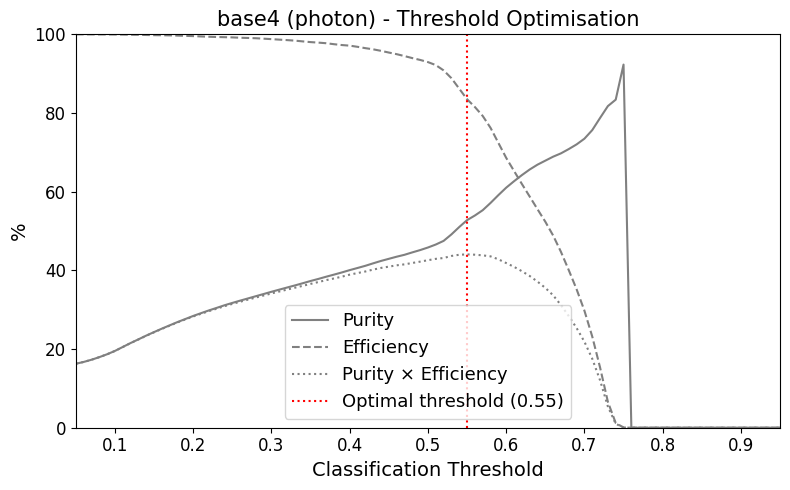

=== base4 (photon) (threshold=0.55) ===
  AUC:        0.928
  Purity:     52.8% ± 0.3%
  Efficiency: 83.5% ± 0.3%
  Product:    44.1%
  saved /home/pemb7173/PDSP-pion-classification/plots/hybrid-classifier/photon/training_base4_photon.pdf


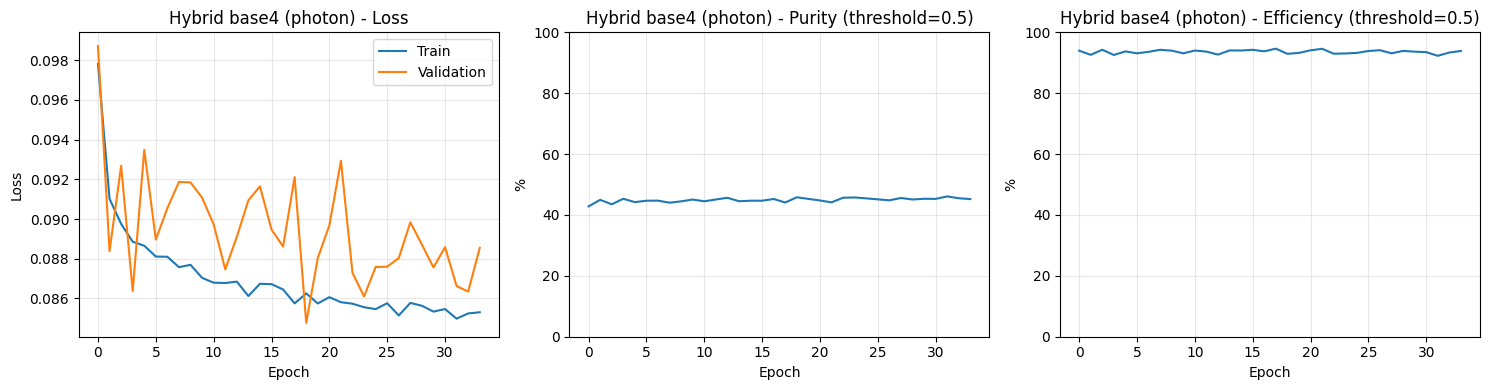

  saved /home/pemb7173/PDSP-pion-classification/plots/hybrid-classifier/photon/roc_base4_photon.pdf


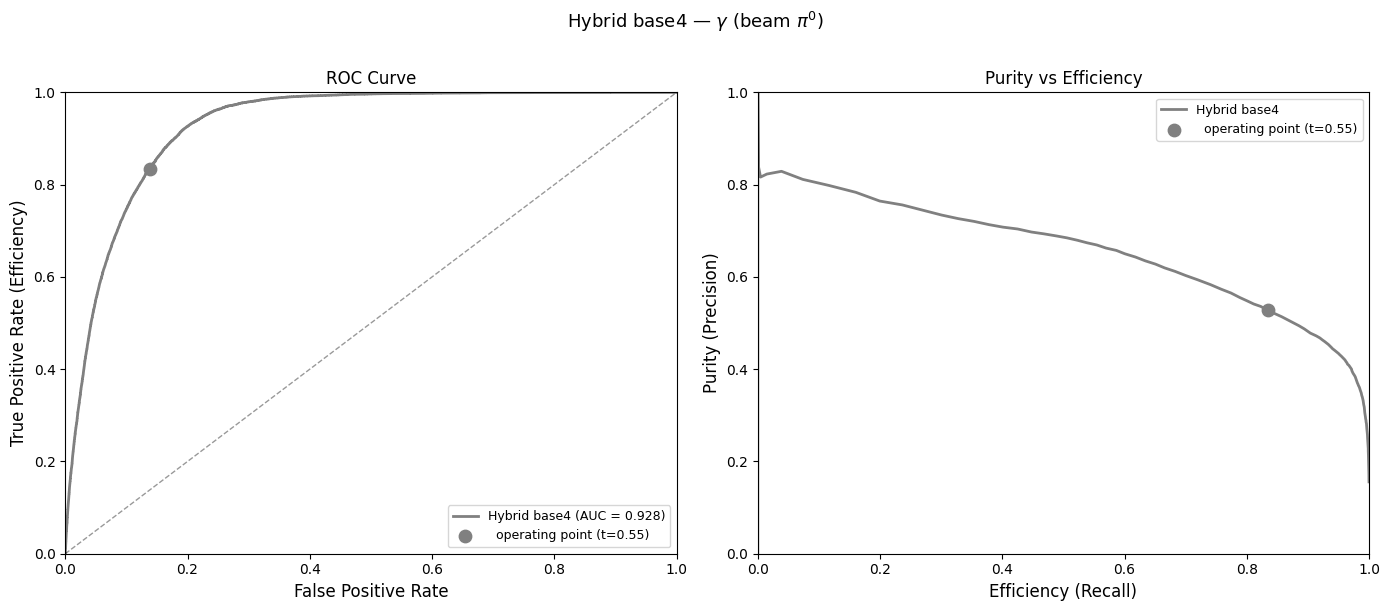

Saved to /home/pemb7173/PDSP-pion-classification/predictions/predictions-mc/hybrid_cnn_mlp_base4_photon.pkl

all8  (8 features)
  ['track_chi2/ndof_proton', 'track_length', 'track_score', 'dEdX_median', 'b', 'd', 'shower_energy', 'beam_angle']
  epoch   1 | train 0.0965 | val 0.0917 | purity 46.0% | efficiency 93.6% (train 45.7% / 93.8%)
  epoch  10 | train 0.0808 | val 0.0825 | purity 51.5% | efficiency 92.4% (train 51.1% / 92.6%)
  epoch  20 | train 0.0794 | val 0.0788 | purity 52.2% | efficiency 92.4% (train 52.0% / 92.7%)
  epoch  30 | train 0.0788 | val 0.0808 | purity 51.8% | efficiency 93.0% (train 51.5% / 93.3%)
  early stop at epoch 34
  best validation loss: 0.0756
  34 epochs in 3761s (110.6s per epoch)
  saved /home/pemb7173/PDSP-pion-classification/plots/hybrid-classifier/photon/threshold_all8_photon.pdf


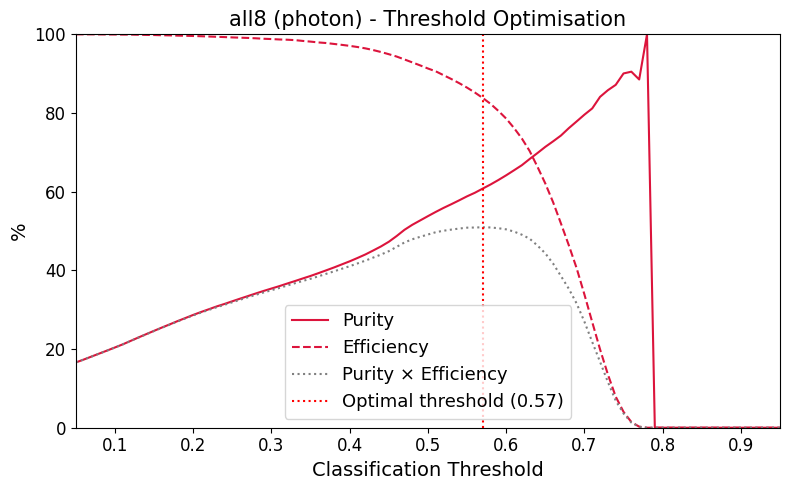

=== all8 (photon) (threshold=0.57) ===
  AUC:        0.945
  Purity:     60.8% ± 0.3%
  Efficiency: 83.8% ± 0.3%
  Product:    51.0%
  saved /home/pemb7173/PDSP-pion-classification/plots/hybrid-classifier/photon/training_all8_photon.pdf


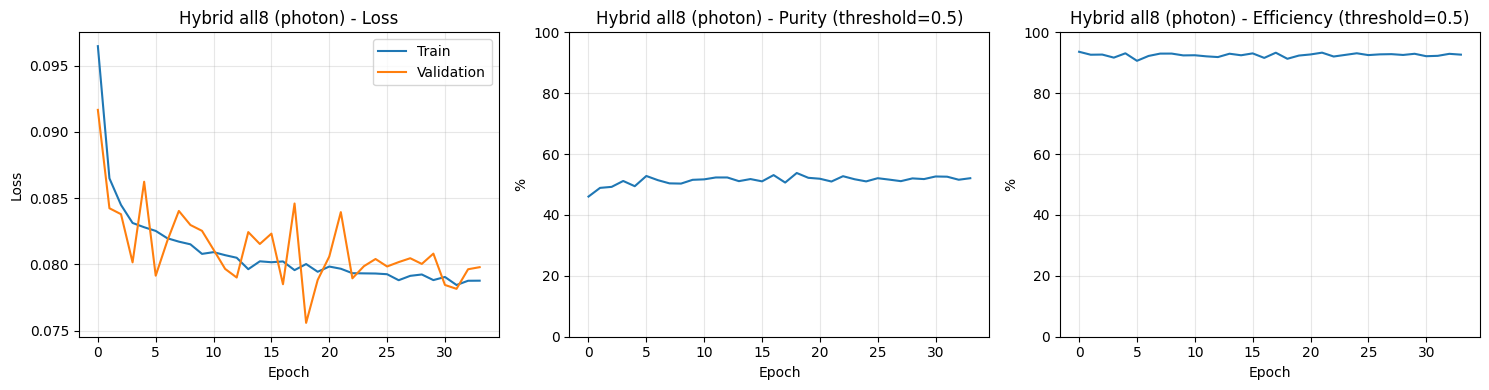

  saved /home/pemb7173/PDSP-pion-classification/plots/hybrid-classifier/photon/roc_all8_photon.pdf


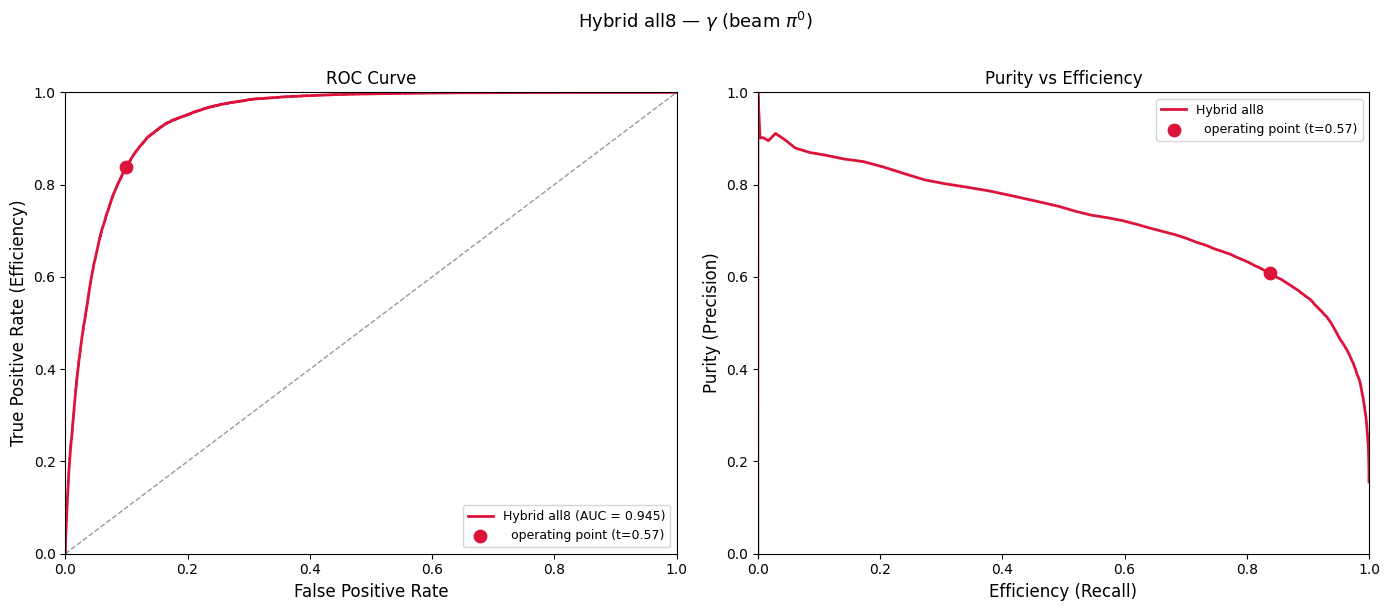

Saved to /home/pemb7173/PDSP-pion-classification/predictions/predictions-mc/hybrid_cnn_mlp_all8_photon.pkl


In [9]:
results, histories, timings = {}, {}, {}

for setname, feats in FEATURE_SETS.items():
    summ_train, summ_test, n_summary = summary_for(setname)
    print(f"\n{'='*72}\n{setname}  ({n_summary} features)\n  {feats}\n{'='*72}")

    train_loader, eval_train_loader, test_loader = make_loaders(summ_train, summ_test)

    # Identical initialisation for every configuration, so a difference in the
    # table is a difference in the inputs and not in the starting weights.
    torch.manual_seed(42)
    np.random.seed(42)

    model = HybridCNNMLP(n_summary=n_summary).to(device)
    model, hist, timing = train_model(model, train_loader, eval_train_loader,
                                      test_loader, setname)
    histories[setname] = hist
    timings[setname]   = timing
    with open(PLOTS_DIR / f"history_{setname}_{TARGET}.pkl", "wb") as f:
        pickle.dump(hist, f)

    _, _, _, probs, labels = evaluate_model(model, test_loader, FocalLoss(gamma=2.0))

    t = optimise_threshold(probs, labels, label=f"{setname} ({TARGET})",
                           color=COLOURS[setname],
                           save_path=PLOTS_DIR / f"threshold_{setname}_{TARGET}.pdf")

    plot_training_curves(hist, f"Hybrid {setname} ({TARGET})",
                         save_path=PLOTS_DIR / f"training_{setname}_{TARGET}.pdf")

    plot_roc_and_purity_efficiency(
        [{'probs': probs, 'labels': labels, 'threshold': t,
          'color': COLOURS[setname], 'label': f'Hybrid {setname}'}],
        title=f"Hybrid {setname} — {cfg['signal_name']}",
        save_path=PLOTS_DIR / f"roc_{setname}_{TARGET}.pdf")

    results[setname] = save_results(
        probs, labels, t,
        model_name=f"Hybrid {setname} -- {TARGET} target",
        save_path=PRED_MC_DIR / f"{BASE}_{setname}{cfg['suffix']}.pkl",
    )
    torch.save(model.state_dict(),
               MODELS_DIR / f"{BASE}_{setname}{cfg['suffix']}.pt")

    if setname == HEADLINE:
        headline_model = model
        headline_probs, headline_labels, headline_t = probs, labels, t

## comparison table

In [10]:
base = results['base4']
base_pxe = 100 * base['purity'] * base['efficiency']

print(f"{'set':<12}{'n':>4}{'AUC':>8}{'purity':>10}{'efficiency':>12}"
      f"{'P x E':>9}{'vs base4':>11}")
print("-" * 66)
for k, r in results.items():
    pxe = 100 * r['purity'] * r['efficiency']
    print(f"{k:<12}{len(FEATURE_SETS[k]):>4}{r['auc']:>8.3f}"
          f"{100*r['purity']:>9.1f}%{100*r['efficiency']:>11.1f}%"
          f"{pxe:>8.1f}%{pxe - base_pxe:>+10.1f}pp")

print("\nbase4 is the control: photons should give ~53.5% purity, ~82.3% "
      "efficiency, AUC 0.928.")

set            n     AUC    purity  efficiency    P x E   vs base4
------------------------------------------------------------------
base4          4   0.928     52.8%       83.5%    44.1%      +0.0pp
all8           8   0.945     60.8%       83.8%    51.0%      +6.9pp

base4 is the control: photons should give ~53.5% purity, ~82.3% efficiency, AUC 0.928.


## ROC comparison

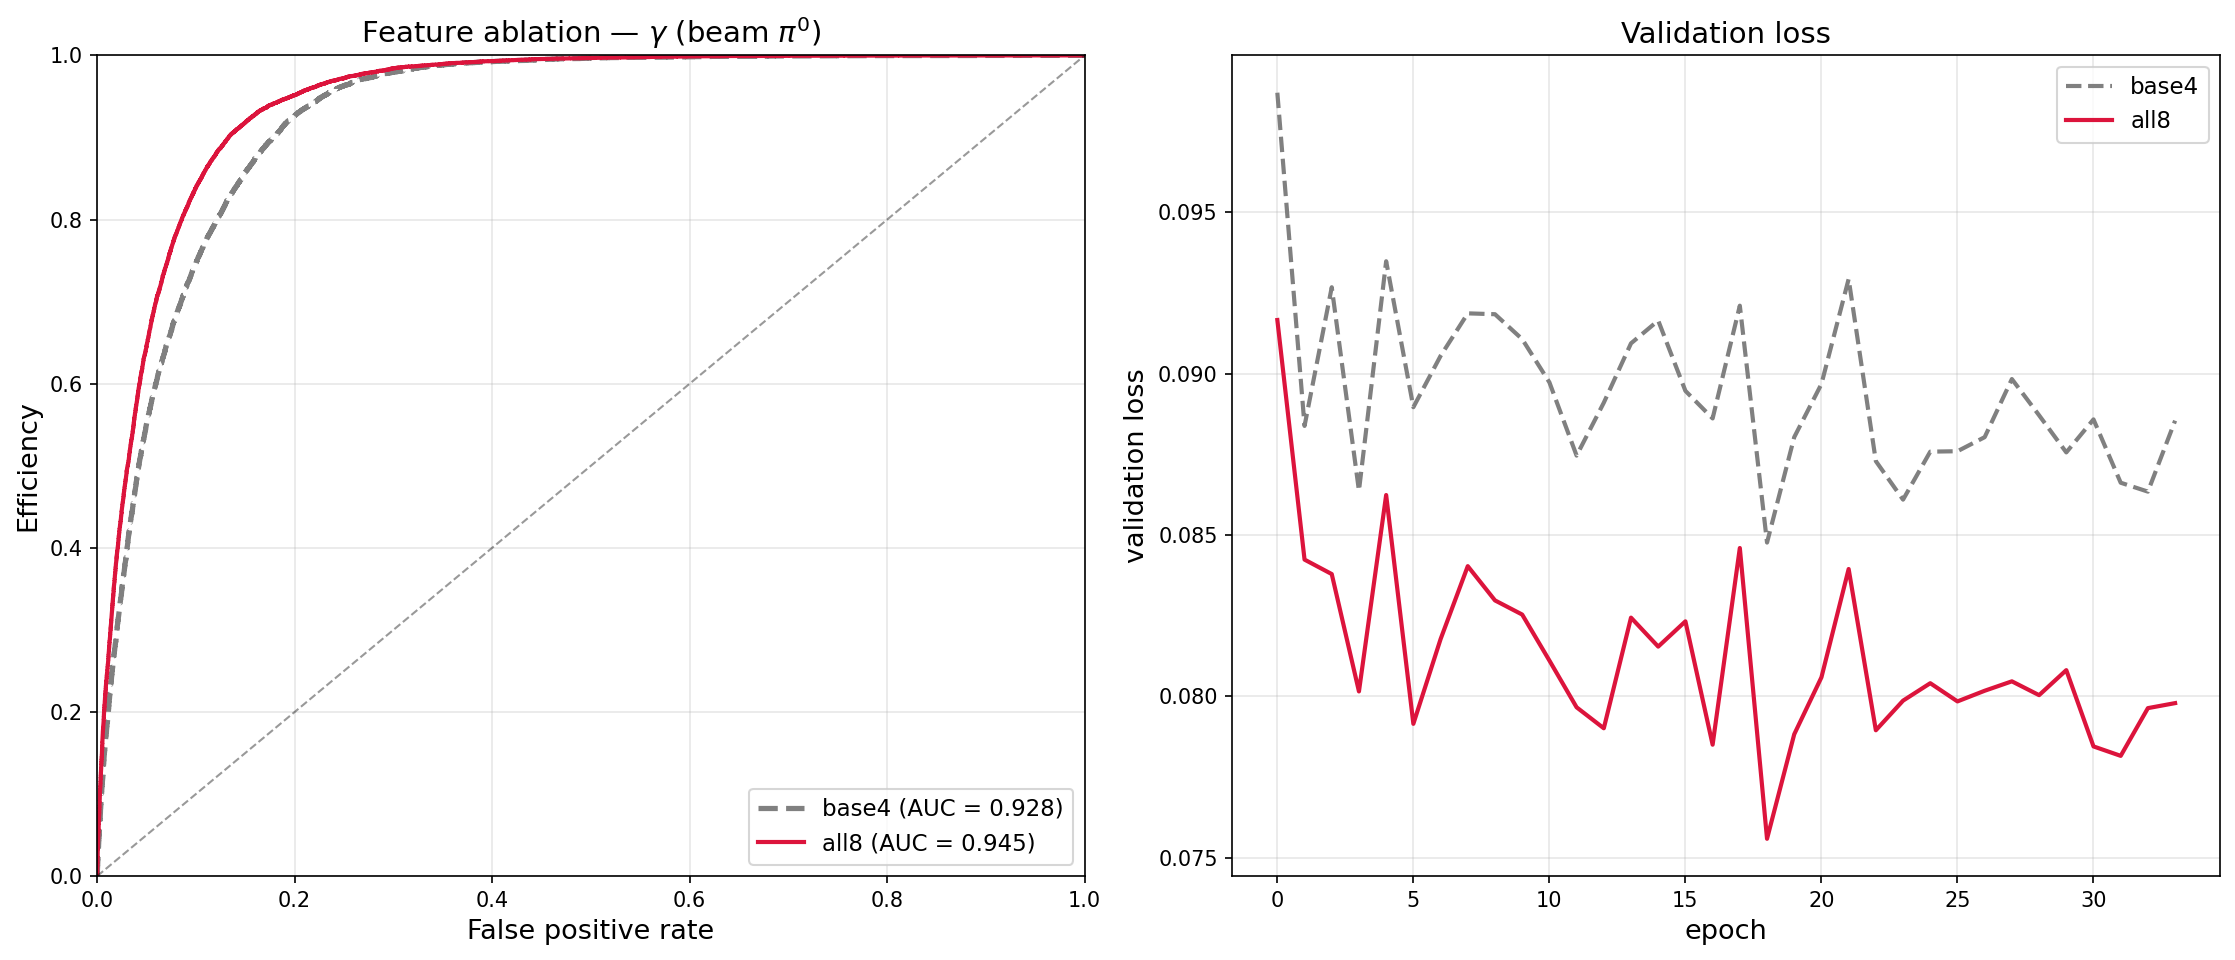

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5), dpi=150)
for k, r in results.items():
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    ax[0].plot(fpr, tpr, color=COLOURS[k], lw=2.5 if k == 'base4' else 2,
               ls='--' if k == 'base4' else '-',
               label=f"{k} (AUC = {sk_auc(fpr, tpr):.3f})")
    ax[1].plot(histories[k]['val_loss'], color=COLOURS[k],
               ls='--' if k == 'base4' else '-', lw=2, label=k)

ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1)
ax[0].set_xlabel('False positive rate', fontsize=13)
ax[0].set_ylabel('Efficiency', fontsize=13)
ax[0].set_title(f"Feature ablation — {cfg['signal_name']}", fontsize=14)
ax[0].legend(fontsize=11); ax[0].grid(alpha=0.3)
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)

ax[1].set_xlabel('epoch', fontsize=13)
ax[1].set_ylabel('validation loss', fontsize=13)
ax[1].set_title('Validation loss', fontsize=14)
ax[1].legend(fontsize=11); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / f"ablation_{TARGET}.pdf", bbox_inches='tight')
plt.show()

## Train vs test diagnostic

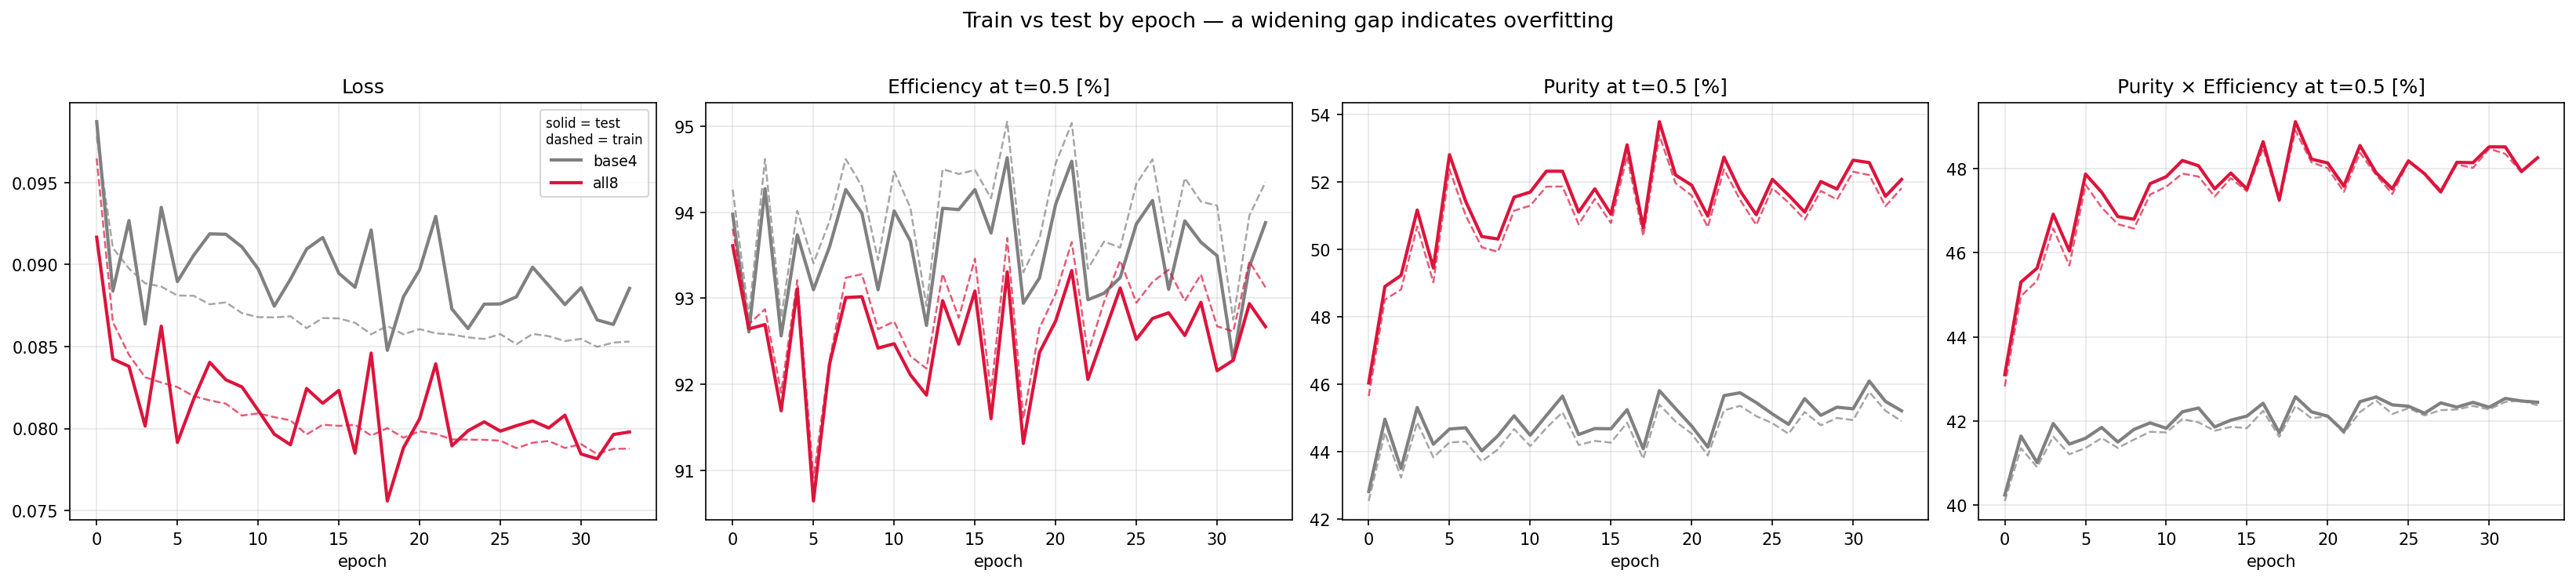

set           epochs   train purity   test purity      gap
----------------------------------------------------------
base4             34          44.9%         45.2%    -0.3pp
all8              34          51.8%         52.1%    -0.3pp

A small positive gap is expected. A large or widening one means the model is fitting the training sample specifically.


In [19]:
# Will's Figure 4 plotted purity and efficiency for the training and test
# samples against max depth; the divergence between them is the overfitting
# signal. This is the same idea against epoch.
#
# Read the GAP between solid and dashed, not the absolute values: purity and
# efficiency here are at a fixed threshold of 0.5, not the optimised one.
fig, ax = plt.subplots(1, 4, figsize=(22, 4.8), dpi=150)

for k, h in histories.items():
    c = COLOURS[k]
    te = h['train_epoch']
    ax[0].plot(h['val_loss'],   color=c, lw=2, label=k)
    ax[0].plot(h['train_loss'], color=c, lw=1.2, ls='--', alpha=0.7)
    ax[1].plot([100*v for v in h['efficiency']], color=c, lw=2, label=k)
    ax[1].plot(te, [100*v for v in h['train_efficiency']], color=c, lw=1.2,
               ls='--', alpha=0.7)
    ax[2].plot([100*v for v in h['purity']], color=c, lw=2, label=k)
    ax[2].plot(te, [100*v for v in h['train_purity']], color=c, lw=1.2,
               ls='--', alpha=0.7)
    ax[3].plot([100*p*e for p, e in zip(h['purity'], h['efficiency'])],
               color=c, lw=2, label=k)
    ax[3].plot(te, [100*p*e for p, e in zip(h['train_purity'], h['train_efficiency'])],
               color=c, lw=1.2, ls='--', alpha=0.7)

for a, t in zip(ax, ['Loss', 'Efficiency at t=0.5 [%]', 'Purity at t=0.5 [%]', 'Purity × Efficiency at t=0.5 [%]']):
    a.set_xlabel('epoch'); a.set_title(t); a.grid(alpha=0.3)
ax[0].legend(fontsize=9, title='solid = test\ndashed = train', title_fontsize=8)

fig.suptitle('Train vs test by epoch — a widening gap indicates overfitting',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"overfitting_{TARGET}.pdf", bbox_inches='tight')
plt.show()

print(f"{'set':<12}{'epochs':>8}{'train purity':>15}{'test purity':>14}{'gap':>9}")
print("-" * 58)
for k, h in histories.items():
    gtr, gte = 100*h['train_purity'][-1], 100*h['purity'][-1]
    print(f"{k:<12}{len(h['val_loss']):>8}{gtr:>14.1f}%{gte:>13.1f}%{gtr-gte:>+8.1f}pp")
print("\nA small positive gap is expected. A large or widening one means the "
      "model is fitting the training sample specifically.")

## training time 

In [13]:
timing_path = PLOTS_DIR / f"timings_{TARGET}.json"
with open(timing_path, "w") as f:
    json.dump({
        'device': str(device),
        'n_train': int(len(y_train)),
        'n_test': int(len(y_test)),
        'batch_size': BATCH_SIZE,
        'train_eval_every': TRAIN_EVAL_EVERY,
        'configurations': {k: {**v, 'n_features': len(FEATURE_SETS[k])}
                           for k, v in timings.items()},
    }, f, indent=2)

print(f"device: {device}   train {len(y_train):,}   test {len(y_test):,}\n")
print(f"{'set':<12}{'n feat':>8}{'epochs':>8}{'total':>10}{'per epoch':>12}")
print("-" * 50)
for k, v in timings.items():
    print(f"{k:<12}{len(FEATURE_SETS[k]):>8}{v['epochs']:>8}"
          f"{v['seconds']:>9.0f}s{v['s_per_epoch']:>11.1f}s")
print(f"\ntotal: {sum(v['seconds'] for v in timings.values())/60:.1f} min")
print(f"saved {timing_path}")

device: cpu   train 507,265   test 126,817

set           n feat  epochs     total   per epoch
--------------------------------------------------
base4              4      34     3774s      111.0s
all8               8      34     3761s      110.6s

total: 125.6 min
saved /home/pemb7173/PDSP-pion-classification/plots/hybrid-classifier/photon/timings_photon.json


## false positives by species

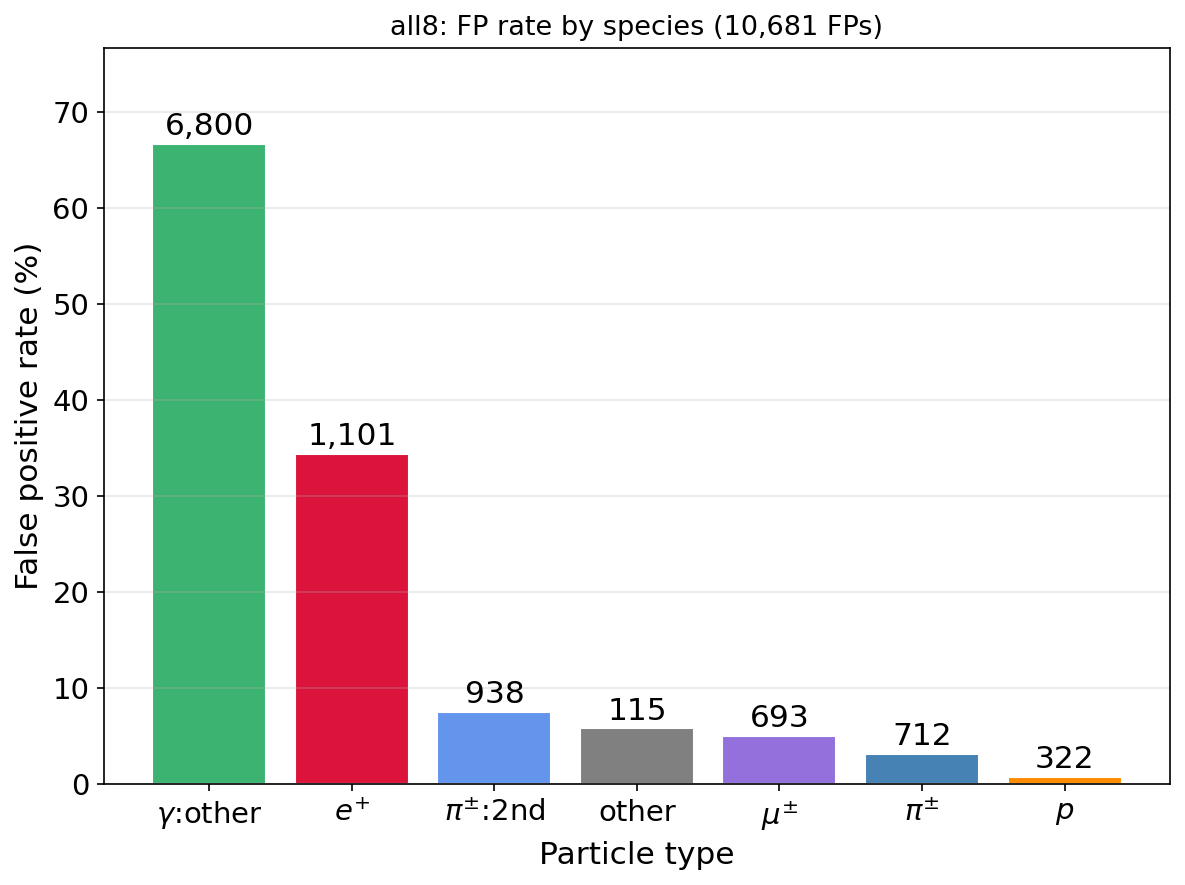


$\gamma$:other: 6,800 of 10,681 false positives (63.7%)


In [14]:
with open(PREPARED_DIR / "test_tracks.pkl", "rb") as f:
    test_tracks = pickle.load(f)
assert len(test_tracks) == len(headline_labels), \
    "test_tracks and predictions are misaligned -- re-run data-preparation"

final_preds = (headline_probs >= headline_t).astype(int)
fp_mask = (final_preds == 1) & (headline_labels == 0)

fp_counts    = Counter(species_label(test_tracks[i]) for i in np.where(fp_mask)[0])
total_counts = Counter(species_label(test_tracks[i])
                       for i in np.where(headline_labels == 0)[0])

classes = sorted(total_counts, key=lambda c: -fp_counts.get(c, 0) / total_counts[c])
rates   = [100 * fp_counts.get(c, 0) / total_counts[c] for c in classes]

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
bars = ax.bar(range(len(classes)), rates,
              color=[SPECIES_COLORS.get(c, 'grey') for c in classes],
              edgecolor='white')
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, fontsize=15)
ax.set_ylabel('False positive rate (%)', fontsize=15)
ax.set_xlabel('Particle type', fontsize=15)
ax.set_title(f'{HEADLINE}: FP rate by species ({int(fp_mask.sum()):,} FPs)',
             fontsize=13)
ax.tick_params(labelsize=14)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(rates) * 1.15)
for bar, c in zip(bars, classes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{fp_counts.get(c, 0):,}', ha='center', va='bottom', fontsize=15)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"fp_by_species_{HEADLINE}_{TARGET}.pdf", bbox_inches='tight')
plt.show()

# For photons this is the number the provenance features were meant to move.
if cfg['main_bkg'] in fp_counts:
    n = fp_counts[cfg['main_bkg']]
    print(f"\n{cfg['main_bkg']}: {n:,} of {int(fp_mask.sum()):,} false positives "
          f"({100*n/fp_mask.sum():.1f}%)")

## confusion matrix

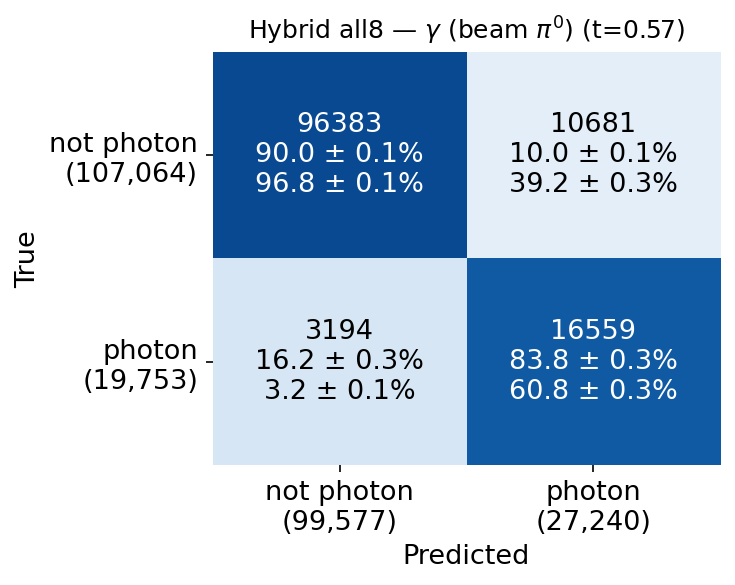

In [15]:
def plot_cm_heatmap(labels, preds, threshold, title, figsize=(5, 4), save_path=None):
    cm, info, raw_names = create_confusion_matrix(labels, preds)
    cm, info = cm[::-1], info[::-1]     # undoes the reversal inside the helper

    def _swap(s):
        a, b, c = s.split('\n')
        return f'{a}\n{c}\n{b}'
    info = np.vectorize(_swap)(info)

    names = [{'0': f'not {TARGET}', '1': TARGET}.get(n, n) for n in raw_names]
    col_totals, row_totals = cm.sum(axis=0), cm.sum(axis=1)
    row_norm = cm / row_totals[:, None].clip(min=1)

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    ax.imshow(row_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, info[i][j], ha='center', va='center', fontsize=13,
                    color='white' if row_norm[i, j] > 0.6 else 'black')
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels([f'{names[j]}\n({col_totals[j]:,})'
                        for j in range(len(names))], fontsize=13)
    ax.set_yticklabels([f'{names[i]}\n({row_totals[i]:,})'
                        for i in range(len(names))], fontsize=13)
    ax.set_xlabel('Predicted', fontsize=13); ax.set_ylabel('True', fontsize=13)
    ax.set_title(f'{title} (t={threshold:.2f})', fontsize=12)
    ax.spines[:].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


plot_cm_heatmap(headline_labels, final_preds, headline_t,
                f"Hybrid {HEADLINE} — {cfg['signal_name']}",
                save_path=PLOTS_DIR / f"confusion_{HEADLINE}_{TARGET}.pdf")

## summary for the promoted model

In [16]:
# model-comparison, topology-selection and the analysis notebooks all read the
# unsuffixed filename. Copy the chosen configuration there so nothing
# downstream needs editing.
import shutil

src_pred  = PRED_MC_DIR / f"{BASE}_{HEADLINE}{cfg['suffix']}.pkl"
dst_pred  = PRED_MC_DIR / f"{BASE}{cfg['suffix']}.pkl"
src_model = MODELS_DIR  / f"{BASE}_{HEADLINE}{cfg['suffix']}.pt"
dst_model = MODELS_DIR  / f"{BASE}{cfg['suffix']}.pt"

shutil.copy(src_pred, dst_pred)
shutil.copy(src_model, dst_model)

N_SUMMARY_HEADLINE = len(FEATURE_SETS[HEADLINE])
print(f"promoted {HEADLINE} ({N_SUMMARY_HEADLINE} features):")
print(f"  {dst_pred}")
print(f"  {dst_model}")
print("\nRe-run downstream with this target: model-comparison, plot-scatter,")
print("contamination-study, shower-observables, event-analysis,")
print("data-mc-comparison, topology-selection.")

promoted all8 (8 features):
  /home/pemb7173/PDSP-pion-classification/predictions/predictions-mc/hybrid_cnn_mlp_photon.pkl
  /home/pemb7173/PDSP-pion-classification/models/hybrid_cnn_mlp_photon.pt

Re-run downstream with this target: model-comparison, plot-scatter,
contamination-study, shower-observables, event-analysis,
data-mc-comparison, topology-selection.


## run on real data

In [17]:
with open(PREPARED_DATA_DIR / "data_inference.pkl", "rb") as f:
    d = pickle.load(f)

# The data summary was built from the full prepared feature list, so select the
# same columns the headline model was trained on.
cols = [COL[k] for k in FEATURE_SETS[HEADLINE]]
seq_data  = d["sequences"][:, :, 0:1]
summ_data = d["summary"][:, cols]
mask_data = d["masks"]
evt, pid  = d["event_number"], d["PFO_ID"]
assert summ_data.shape[1] == N_SUMMARY_HEADLINE
print(f"Data PFOs: {len(pid):,}, summary {summ_data.shape}")

headline_model.eval()
seq  = torch.FloatTensor(seq_data).permute(0, 2, 1).to(device)
summ = torch.FloatTensor(summ_data).to(device)
m    = torch.FloatTensor(mask_data).to(device)

probs = []
with torch.no_grad():
    for i in range(0, len(seq), 4096):
        probs.append(torch.sigmoid(
            headline_model(seq[i:i+4096], summ[i:i+4096], m[i:i+4096])).cpu().numpy())
data_probs = np.concatenate(probs)
data_preds = (data_probs >= headline_t).astype(int)

print(f"Hybrid {HEADLINE} on data ({TARGET}): {data_preds.sum():,} / "
      f"{len(data_preds):,} ({100*data_preds.mean():.1f}%) tagged "
      f"at t={headline_t:.3f}")

with open(DATA_PRED_PATH, "wb") as f:
    pickle.dump({"probs": data_probs, "preds": data_preds,
                 "threshold": headline_t,
                 "event_number": evt, "PFO_ID": pid,
                 "features": FEATURE_SETS[HEADLINE],
                 "model_name": f"Hybrid {HEADLINE} ({TARGET})"}, f)
print(f"Saved {DATA_PRED_PATH}")

Data PFOs: 353,652, summary (353652, 8)


Hybrid all8 on data (photon): 88,530 / 353,652 (25.0%) tagged at t=0.570
Saved /home/pemb7173/PDSP-pion-classification/predictions/predictions-data/hybrid_data_predictions_photon.pkl


## reload w/o retraining

In [18]:
# Requires cells 1, 2, 4 only (setup, data, model definitions).
SET = HEADLINE          # or any key of FEATURE_SETS

with open(PRED_MC_DIR / f"{BASE}_{SET}{cfg['suffix']}.pkl", "rb") as f:
    saved = pickle.load(f)
headline_probs  = saved["probs"]
headline_labels = saved["labels"]
headline_t      = saved["threshold"]
final_preds     = (headline_probs >= headline_t).astype(int)

N_SUMMARY_HEADLINE = len(FEATURE_SETS[SET])
headline_model = HybridCNNMLP(n_summary=N_SUMMARY_HEADLINE).to(device)
headline_model.load_state_dict(
    torch.load(MODELS_DIR / f"{BASE}_{SET}{cfg['suffix']}.pt", map_location=device))
headline_model.eval()

print(f"{saved['model_name']}   t={headline_t:.3f}   AUC={saved['auc']:.3f}   "
      f"purity {100*saved['purity']:.1f}%   efficiency {100*saved['efficiency']:.1f}%")

Hybrid all8 -- photon target   t=0.570   AUC=0.945   purity 60.8%   efficiency 83.8%
